# Scalar conservation laws: shocks and rarefactions

For Burgers flux $f(u)=u^2/2$, Riemann data provide a compact tutorial on weak solutions, Rankine–Hugoniot speed, and entropy selection.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Derivation of the shockFor $u_t+f(u)_x=0$, a discontinuity connecting $u_L$ to $u_R$ moves with Rankine–Hugoniot speed$$s=\frac{f(u_L)-f(u_R)}{u_L-u_R}.$$With $f(u)=u^2/2$, $u_L=1$, and $u_R=0$,$$s=\frac{1/2-0}{1-0}=\frac12.$$Because the convex-flux characteristic speeds satisfy $f'(1)>s>f'(0)$, this is the entropy-admissible shock.

In [3]:
x, t = sp.symbols("x t", positive=True, real=True)
z = sp.symbols("z", real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,t),t) + sp.diff(u(x,t)**2/2, x), 0)
problem = pds.build_pde_problem(eq, u(x,t), (x,t))
recognition, plan = show_plan(problem)

Recognition: (PDERecognitionRecord(family='scalar_conservation_law', recognized=True, solver_hint='conservation_law', tags=('weak_solution', 'riemann_ready'), metadata={'canonical_family': 'transport_reaction'}), PDERecognitionRecord(family='quasilinear_scalar_ivp', recognized=True, solver_hint='quasilinear_implicit', tags=('characteristics',), metadata={}))Top plan steps:  first_order_nonlinear_auto                 score=86  charpit                                    score=84  conservation_law                           score=82  complete_integral                          score=78  invariant_reduction_auto                   score=74  first_order                                score=70

PDEIVPResult scalar_conservation_riemann_shock

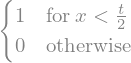

In [4]:
from pdesolve.classical import solve_scalar_conservation_law_riemann_general
result = solve_scalar_conservation_law_riemann_general(z**2/2, 1, 0, x=x, t=t, u_symbol=z)
print(type(result).__name__, result.method)
display(result.solution)

## 2. Weak verification semanticsPointwise residuals are not the right criterion at a shock. Here we directly verify the jump speed, while PDESolve also exposes weak/admissibility utilities for supported scalar problems.

In [5]:
flux = z**2/2
s = sp.simplify((flux.subs(z,1)-flux.subs(z,0))/(1-0))
print("Rankine–Hugoniot speed:", s)
print("Lax inequalities:", sp.diff(flux,z).subs(z,1), ">", s, ">", sp.diff(flux,z).subs(z,0))
assert s == sp.Rational(1,2)

Rankine–Hugoniot speed: 1/2Lax inequalities: 1 > 1/2 > 0

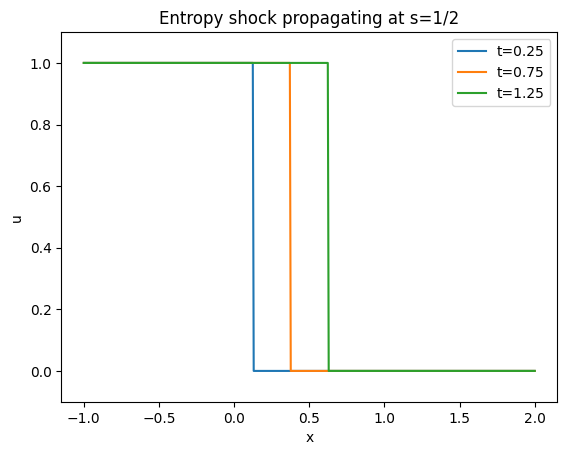

In [6]:
xx = np.linspace(-1, 2, 500)
fig, ax = plt.subplots()
for tv in [0.25, 0.75, 1.25]:
    yy = np.where(xx < 0.5*tv, 1.0, 0.0)
    ax.plot(xx, yy, label=f"t={tv:g}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_ylim(-0.1,1.1); ax.set_title("Entropy shock propagating at s=1/2")
ax.legend(); plt.show()

## 3. Variation and exercisesReverse the Riemann states to obtain a rarefaction. Then: (1) derive its self-similar fan $u=x/t$ between the characteristic edges; (2) compare shock and rarefaction entropy conditions; (3) try a different convex flux.

PDEIVPResult scalar_conservation_riemann_rarefaction

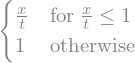

In [7]:
r2 = solve_scalar_conservation_law_riemann_general(z**2/2, 0, 1, x=x, t=t, u_symbol=z)
print(type(r2).__name__, r2.method); display(r2.solution)